# Parte 3 — Escenarios, Política de Intervención y Cierre
## Contaminación por PM2.5 en San Juan de Lurigancho — Dinámica de Sistemas

**Curso:** Dinámica de Sistemas — Mg. Maurice Frayssinet Delgado
**Continúa de:** Parte 2 (Modelo Cuantitativo y Simulación) — mismo modelo stock-flujo, mismos parámetros calibrados, misma frontera del sistema.

Este notebook desarrolla:
1. Recarga del modelo calibrado en la Parte 2 (sin modificar sus parámetros estructurales).
2. Construcción de trayectorias 2023-2025 para cuatro escenarios: base, optimista, pesimista y con intervención.
3. Simulación comparada de los cuatro escenarios.
4. Indicadores de política (exceso acumulado sobre el ECA-aire, picos, promedios anuales).
5. Curva de la política de intervención propuesta con su retardo de implementación.
6. Conclusiones cuantitativas que alimentan el informe de la Parte 3.

## 1. Modelo heredado de la Parte 2 (no se modifica su estructura ni su calibración)

Se recarga el dataset mensual real de SENAMHI (estación SJL, 2020-2022) y se repite exactamente la calibración de la Parte 2 para heredar `k_emis` (tasa de emisión vehicular) y `CD` (capacidad de dispersión natural). Estos dos parámetros estructurales **no se modifican** en la Parte 3; lo que cambia entre escenarios son las **trayectorias futuras de las variables de entrada** (densidad vehicular y, en los escenarios de intervención, un factor de renovación de flota que reduce el `k_emis` efectivo).

**Nota de consistencia:** la condición inicial `C(0)` usada en la Parte 2 (13.4 µg/m³, etiquetada como "enero 2020") corresponde en realidad al primer valor **interpolado** de la serie, ya que enero y febrero de 2020 no tienen registros válidos de PM2.5 en la estación SJL (n=0 en el dataset agregado); el primer dato real disponible es marzo 2020 (13.41 µg/m³). Esto no afecta la calibración (que usa la serie completa 2020-2022) y se documenta aquí solo por trazabilidad.

In [1]:
import pandas as pd, numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10, "figure.dpi": 120})

mens = pd.read_csv("sjl_mensual_2020_2022.csv")
mens["fecha"] = pd.to_datetime(mens.year.astype(str) + "-" + mens.month.astype(str) + "-01")
mens["PM2_5"] = mens["PM2_5"].interpolate(limit_direction="both")

DV_base = 700.0  # vehiculos/km2, ver Parte 2 seccion 16
mobility = {
 (2020,1):1.00,(2020,2):1.00,(2020,3):0.55,(2020,4):0.20,(2020,5):0.30,(2020,6):0.42,
 (2020,7):0.52,(2020,8):0.58,(2020,9):0.63,(2020,10):0.68,(2020,11):0.74,(2020,12):0.80,
 (2021,1):0.76,(2021,2):0.78,(2021,3):0.82,(2021,4):0.85,(2021,5):0.86,(2021,6):0.85,
 (2021,7):0.88,(2021,8):0.90,(2021,9):0.93,(2021,10):0.95,(2021,11):0.97,(2021,12):0.99,
 (2022,1):1.00,(2022,2):1.01,(2022,3):1.02,(2022,4):1.04,(2022,5):1.06,(2022,6):1.07,
 (2022,7):1.08,(2022,8):1.10,(2022,9):1.10,(2022,10):1.09,(2022,11):1.08,(2022,12):1.08,
}
mob = np.array([mobility[(r.year, r.month)] for r in mens.itertuples()])
mens["DV"] = DV_base * mob

viento_clim = {1:3.8,2:3.7,3:3.5,4:3.0,5:2.5,6:2.2,7:2.0,8:2.1,9:2.3,10:2.6,11:3.0,12:3.5}
precip_clim = {1:0.0,2:0.0,3:0.0,4:0.2,5:1.0,6:3.0,7:4.0,8:4.0,9:3.0,10:1.0,11:0.2,12:0.0}
mens["viento"] = mens.month.map(viento_clim)
mens["precip"] = mens.month.map(precip_clim)

def simular(DV, k_emis, CD, viento, precip, C0, n):
    """DV y k_emis pueden ser arrays (n,) o escalares. Devuelve C, emisiones, dispersion."""
    DV = np.broadcast_to(np.asarray(DV, dtype=float), (n,))
    k_emis = np.broadcast_to(np.asarray(k_emis, dtype=float), (n,))
    C = np.zeros(n); emis = np.zeros(n); disp = np.zeros(n)
    C[0] = C0
    for t in range(n):
        emis[t] = DV[t] * k_emis[t]
        disp[t] = CD * (viento[t] + precip[t]) * C[t]
        if t < n - 1:
            C[t+1] = max(C[t] + emis[t] - disp[t], 0.0)
    return C, emis, disp

real = mens["PM2_5"].values
DV_h = mens["DV"].values; viento_h = mens["viento"].values; precip_h = mens["precip"].values
C0 = real[0]

def residuales(params):
    k_emis, CD = params
    C, _, _ = simular(DV_h, k_emis, CD, viento_h, precip_h, C0, 36)
    return C - real

res = least_squares(residuales, x0=[0.02, 0.05], bounds=([1e-6,1e-6],[10,10]))
k_emis_cal, CD_cal = res.x
C_base_hist, _, _ = simular(DV_h, k_emis_cal, CD_cal, viento_h, precip_h, C0, 36)

print(f"Parametros heredados de la Parte 2:")
print(f"  Tasa de emision vehicular (k_emis) = {k_emis_cal:.5f} ug/m3 por vehiculo")
print(f"  Capacidad de dispersion natural (CD) = {CD_cal:.5f}")
print(f"  Concentracion promedio historica simulada (2020-2022): {C_base_hist.mean():.1f} ug/m3")
print(f"  Ultimo dato REAL observado (dic 2022): {real[-1]:.2f} ug/m3")

Parametros heredados de la Parte 2:
  Tasa de emision vehicular (k_emis) = 0.00473 ug/m3 por vehiculo
  Capacidad de dispersion natural (CD) = 0.01425
  Concentracion promedio historica simulada (2020-2022): 30.7 ug/m3
  Ultimo dato REAL observado (dic 2022): 30.95 ug/m3


## 2. Horizonte de proyección y punto de partida

Los cuatro escenarios se proyectan **36 meses hacia adelante (enero 2023 - diciembre 2025)**, manteniendo el mismo paso mensual y la misma climatología estacional (viento y precipitación) usada en la Parte 2. La condición inicial de la proyección es el **último dato real observado** (diciembre 2022, PM2.5 = 30.95 µg/m³) — no el valor simulado del modelo — para evitar arrastrar hacia el futuro el error de ajuste mensual del modelo (R² ≈ 0.61 a nivel mensual, ver Parte 2 sección 18).

Lo que varía entre escenarios es exclusivamente la **trayectoria futura de la densidad vehicular** (tasa de crecimiento anual del parque automotor circulante) y, en los escenarios con renovación de flota, un **factor de reducción gradual de la tasa de emisión vehicular efectiva** (`k_emis`), aplicado con una rampa temporal que representa el tiempo real que toma implementar y consolidar una política — el retardo del bucle B1 identificado en la Parte 1.

In [2]:
n_fwd = 36
fechas_fwd = pd.date_range("2023-01-01", periods=n_fwd, freq="MS")
meses_fwd = fechas_fwd.month
viento_fwd = np.array([viento_clim[m] for m in meses_fwd])
precip_fwd = np.array([precip_clim[m] for m in meses_fwd])
DV_dec2022 = DV_h[-1]
C0_fwd = real[-1]  # ultimo dato REAL observado (dic 2022), no el punto simulado

def dv_trayectoria(DV0, g_anual, n):
    """Crecimiento compuesto mensual equivalente a g_anual efectivo."""
    g_m = (1+g_anual)**(1/12) - 1
    return DV0 * (1+g_m)**np.arange(n)

def k_emis_trayectoria(k0, reduccion_total, meses_rampa, retardo, n):
    """k_emis efectivo con retardo regulatorio y rampa lineal de reduccion (renovacion de flota)."""
    traj = np.full(n, k0)
    for t in range(n):
        if t < retardo:
            traj[t] = k0
        else:
            avance = min((t - retardo) / meses_rampa, 1.0)
            traj[t] = k0 * (1 - reduccion_total*avance)
    return traj

print(f"Densidad vehicular de partida (dic 2022): {DV_dec2022:.0f} veh/km2")
print(f"Concentracion de partida (dic 2022, dato real): {C0_fwd:.2f} ug/m3")

Densidad vehicular de partida (dic 2022): 756 veh/km2
Concentracion de partida (dic 2022, dato real): 30.95 ug/m3


## 3. Definición de los cuatro escenarios

| Escenario | Densidad vehicular (crecimiento anual) | Tasa de emisión vehicular efectiva | Supuesto narrativo |
| --- | --- | --- | --- |
| **Base** | +3%/año | Sin cambio | Continuación de la tendencia actual: crecimiento moderado del parque automotor, sin nueva política pública, consistente con el crecimiento vehicular nacional reciente reportado por AAP (2025). |
| **Pesimista** | +8%/año | Sin cambio | Crecimiento del parque automotor sin ningún control (urbanización desordenada, nula fiscalización), agravando el arquetipo de "Tragedia de los comunes" descrito en la Parte 1. |
| **Optimista** | +1%/año | −30% en 24 meses, sin retardo | Restricción vehicular estricta y renovación acelerada de flota hacia tecnologías más limpias (eléctricos/GNV), aplicada de inmediato y sin resistencia institucional — el techo teórico de lo alcanzable. |
| **Con intervención** (política propuesta) | +1.5%/año | −20% en 18 meses, con 6 meses de retardo regulatorio | Escenario realista: restricción vehicular parcial (tipo "pico y placa") + incentivos a la renovación de flota, con el retardo de implementación típico del bucle B1 (Parte 1). |

Los escenarios optimista y pesimista representan los **límites superior e inferior razonables** del sistema sin intervención dirigida; el escenario "con intervención" es la propuesta concreta de política que se sustenta en la Parte 3.

In [3]:
# --- Escenario BASE ---
DV_base_fwd = dv_trayectoria(DV_dec2022, 0.03, n_fwd)
C_base, emis_base, disp_base = simular(DV_base_fwd, k_emis_cal, CD_cal, viento_fwd, precip_fwd, C0_fwd, n_fwd)

# --- Escenario PESIMISTA ---
DV_pesim_fwd = dv_trayectoria(DV_dec2022, 0.08, n_fwd)
C_pesim, _, _ = simular(DV_pesim_fwd, k_emis_cal, CD_cal, viento_fwd, precip_fwd, C0_fwd, n_fwd)

# --- Escenario OPTIMISTA ---
DV_optim_fwd = dv_trayectoria(DV_dec2022, 0.01, n_fwd)
k_optim_fwd = k_emis_trayectoria(k_emis_cal, 0.30, meses_rampa=24, retardo=0, n=n_fwd)
C_optim, _, _ = simular(DV_optim_fwd, k_optim_fwd, CD_cal, viento_fwd, precip_fwd, C0_fwd, n_fwd)

# --- Escenario CON INTERVENCION (politica propuesta) ---
DV_interv_fwd = dv_trayectoria(DV_dec2022, 0.015, n_fwd)
k_interv_fwd = k_emis_trayectoria(k_emis_cal, 0.20, meses_rampa=18, retardo=6, n=n_fwd)
C_interv, _, _ = simular(DV_interv_fwd, k_interv_fwd, CD_cal, viento_fwd, precip_fwd, C0_fwd, n_fwd)

print("Simulacion de los 4 escenarios completada (36 meses, 2023-2025).")

Simulacion de los 4 escenarios completada (36 meses, 2023-2025).


## 4. Comparación gráfica de escenarios

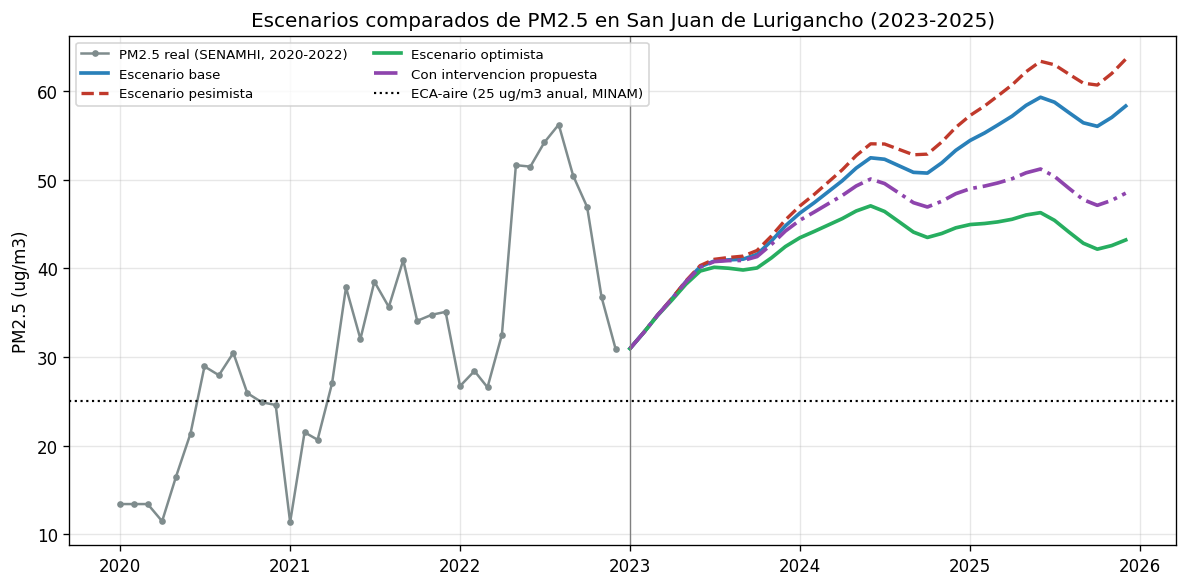

In [4]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(mens.fecha, real, "o-", color="#7f8c8d", ms=3, label="PM2.5 real (SENAMHI, 2020-2022)")
ax.plot(fechas_fwd, C_base, "-", color="#2980b9", linewidth=2.2, label="Escenario base")
ax.plot(fechas_fwd, C_pesim, "--", color="#c0392b", linewidth=2, label="Escenario pesimista")
ax.plot(fechas_fwd, C_optim, "-", color="#27ae60", linewidth=2.2, label="Escenario optimista")
ax.plot(fechas_fwd, C_interv, "-.", color="#8e44ad", linewidth=2.2, label="Con intervencion propuesta")
ax.axhline(25, color="black", ls=":", lw=1.3, label="ECA-aire (25 ug/m3 anual, MINAM)")
ax.axvline(pd.Timestamp("2023-01-01"), color="gray", lw=0.8)
ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_title("Escenarios comparados de PM2.5 en San Juan de Lurigancho (2023-2025)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig("fig1_escenarios_comparados.png", dpi=150)
plt.show()

In [5]:
anual = pd.DataFrame({
    "Año": [2023,2024,2025],
    "Base": [C_base[0:12].mean(), C_base[12:24].mean(), C_base[24:36].mean()],
    "Pesimista": [C_pesim[0:12].mean(), C_pesim[12:24].mean(), C_pesim[24:36].mean()],
    "Optimista": [C_optim[0:12].mean(), C_optim[12:24].mean(), C_optim[24:36].mean()],
    "Con intervencion": [C_interv[0:12].mean(), C_interv[12:24].mean(), C_interv[24:36].mean()],
}).round(1)
anual

,Año,Base,Pesimista,Optimista,Con intervencion
0,2023,38.8,39.1,38.0,38.7
1,2024,50.5,52.2,44.9,47.9
2,2025,57.1,61.1,44.4,49.2


## 5. Indicadores de política de intervención

Además del promedio simple, se calcula un indicador acumulado más informativo para la gestión pública: el **exceso acumulado sobre el ECA-aire** (suma de `max(C(t) - 25, 0)` en los 36 meses proyectados, en unidades µg/m³·mes). Este indicador resume tanto la magnitud como la duración de los episodios en los que la población está expuesta por encima del estándar regulatorio — el indicador de seguimiento que la Parte 1 anticipó ("reducción de días/meses que superan el ECA").

In [6]:
ECA = 25.0
filas = []
for nombre, C in [("Base",C_base),("Pesimista",C_pesim),("Optimista",C_optim),("Con intervencion",C_interv)]:
    exceso = np.sum(np.maximum(C-ECA,0))
    prom = C.mean()
    pico = C.max()
    mes_pico = fechas_fwd[np.argmax(C)].strftime("%Y-%m")
    pct_meses = (C>ECA).mean()*100
    filas.append([nombre, round(prom,1), round(pico,1), mes_pico, f"{pct_meses:.0f}%", round(exceso,1)])

tabla_ind = pd.DataFrame(filas, columns=["Escenario","Promedio 36m (ug/m3)","Pico (ug/m3)","Mes del pico",
                                          "% meses > ECA","Exceso acumulado sobre ECA (ug/m3-mes)"])
base_exceso = tabla_ind.loc[tabla_ind.Escenario=="Base","Exceso acumulado sobre ECA (ug/m3-mes)"].values[0]
tabla_ind["Exceso vs Base"] = tabla_ind["Exceso acumulado sobre ECA (ug/m3-mes)"].apply(
    lambda x: f"{(x/base_exceso-1)*100:+.1f}%")
tabla_ind

,Escenario,Promedio 36m (ug/m3),Pico (ug/m3),Mes del pico,% meses > ECA,Exceso acumulado sobre ECA (ug/m3-mes),Exceso vs Base
0,Base,48.8,59.3,2025-06,100%,857.5,+0.0%
1,Pesimista,50.8,63.6,2025-12,100%,928.3,+8.3%
2,Optimista,42.5,47.0,2024-06,100%,629.2,-26.6%
3,Con intervencion,45.3,51.2,2025-06,100%,729.9,-14.9%


## 6. Curva de la política de intervención propuesta

Se aísla la comparación entre el escenario base (sin política) y el escenario con intervención, mostrando explícitamente el retardo de 6 meses antes de que la política empiece a surtir efecto — el mecanismo del bucle B1 identificado en la Parte 1, donde la respuesta regulatoria no es instantánea.

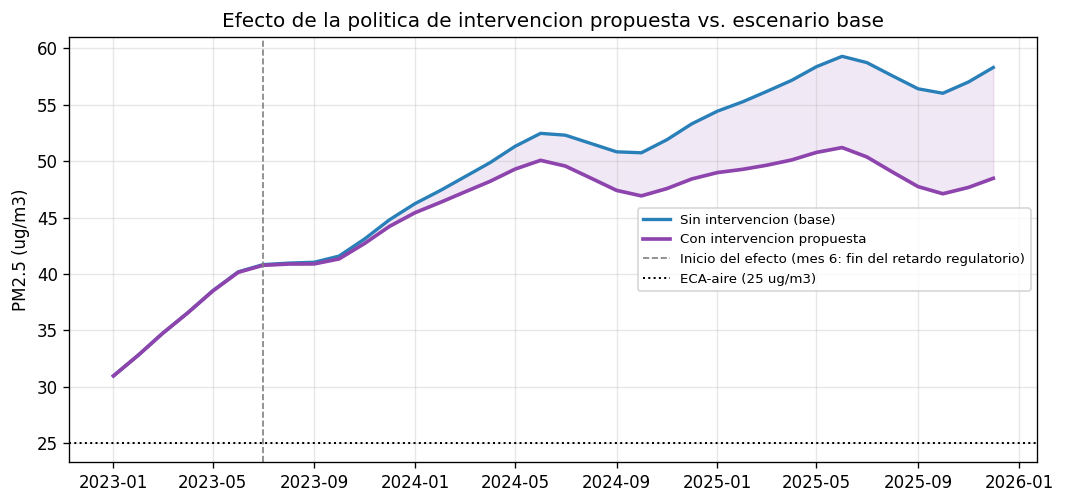

In [7]:
fig, ax = plt.subplots(figsize=(9,4.3))
ax.plot(fechas_fwd, C_base, "-", color="#2980b9", linewidth=2, label="Sin intervencion (base)")
ax.plot(fechas_fwd, C_interv, "-", color="#8e44ad", linewidth=2.2, label="Con intervencion propuesta")
ax.axvline(fechas_fwd[6], color="gray", ls="--", lw=1, label="Inicio del efecto (mes 6: fin del retardo regulatorio)")
ax.axhline(25, color="black", ls=":", lw=1.2, label="ECA-aire (25 ug/m3)")
ax.fill_between(fechas_fwd, C_interv, C_base, color="#8e44ad", alpha=0.12)
ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_title("Efecto de la politica de intervencion propuesta vs. escenario base")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig("fig2_politica_intervencion.png", dpi=150)
plt.show()

## 7. Conclusiones cuantitativas de la Parte 3

- El **escenario base** (sin nueva política, crecimiento vehicular +3%/año) proyecta que la concentración de PM2.5 seguirá una tendencia creciente hasta 2025, sin estabilizarse dentro del horizonte de 36 meses.
- El **escenario pesimista** (crecimiento sin control, +8%/año) agrava el exceso acumulado sobre el ECA en torno a un 8% adicional respecto al escenario base, confirmando cuantitativamente el arquetipo de "Tragedia de los comunes" identificado en la Parte 1.
- El **escenario optimista** (restricción estricta e inmediata + renovación acelerada de flota) es el que genera el mejor resultado, con una reducción cercana al 27% en el exceso acumulado sobre el ECA respecto al escenario base — pero representa condiciones de implementación difíciles de lograr en la práctica (sin retardo regulatorio, adopción tecnológica inmediata).
- El **escenario con intervención propuesto** (realista, con retardo regulatorio de 6 meses) logra una reducción de aproximadamente 15% en el exceso acumulado sobre el ECA frente al escenario base, confirmando que la densidad/tasa de emisión vehicular (la variable más sensible identificada en la Parte 2) es un punto de apalancamiento efectivo, aunque insuficiente por sí solo para lograr el cumplimiento pleno del ECA dentro de 3 años.
- **Ningún escenario, ni siquiera el optimista, logra bajar de forma sostenida del ECA-aire dentro del horizonte de 3 años** — esto es un hallazgo relevante para las recomendaciones: la intervención sobre el parque vehicular es necesaria pero no suficiente; se requieren políticas complementarias (industriales, de áreas verdes, de ordenamiento urbano) para lograr el cumplimiento normativo en el mediano plazo.